Generating synthetic vibration data...
Training data: (4000, 128, 1)
Test data: (1000, 128, 1)
Normal machines: 3494, Failing machines: 1506

BASELINE MODEL: Larger CNN for Vibration Analysis
Baseline model parameters: 304,385
Training baseline model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline accuracy: 1.0000
Baseline model size: 3.54 MB
Baseline inference time (10 samples): 82.6 ms

OPTIMIZED MODEL: Lightweight MobileNet-Style Architecture
Optimized model parameters: 22,945
Parameter reduction: 92.5%
Training optimized model...


Optimized accuracy: 1.0000
Optimized model size: 0.31 MB
Size reduction: 91.3%
Optimized inference time (10 samples): 81.6 ms
Latency improvement: 1.1%

CONVERTING TO TFLITE FOR EDGE DEPLOYMENT
Saved artifact at '/tmp/tmpdhcr944n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 1), dtype=tf.float32, name='keras_tensor_31')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138725328675344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878026064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878023184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878028560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878023952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878026448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878037392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725878022992: TensorSpec(shap

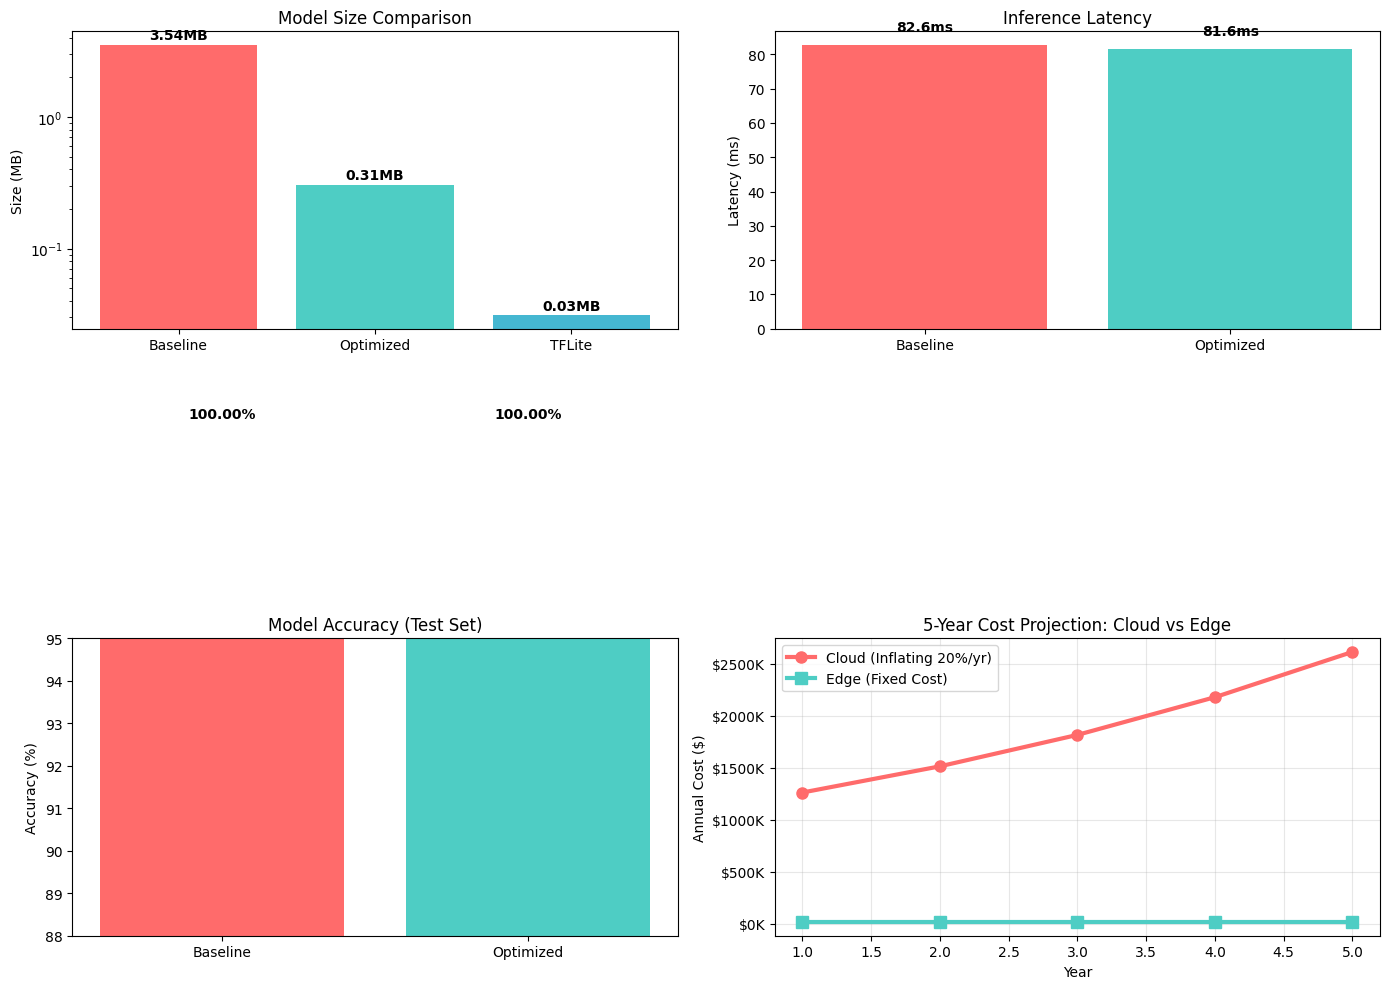

In [2]:
#Industrial Predictive Maintenance
# Vibration/Acoustic Analysis Model Optimization

#Create Synthetic Industrial Data


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Simulate vibration sensor data (accelerometer readings)
# Real-world: 1000s of machines sending 100Hz vibration samples

np.random.seed(42)

def create_synthetic_vibration_data(n_samples=5000):
    """
    Create synthetic vibration data
    Normal machine: clean frequency response
    Failing machine: increased noise + frequency spikes
    """
    X = []
    y = []

    for i in range(n_samples):
        if np.random.random() < 0.7:  # 70% normal machines
            # Normal vibration: clean sine wave + small noise
            t = np.linspace(0, 1, 128)
            vibration = (np.sin(2 * np.pi * 50 * t) +  # 50Hz fundamental
                        0.1 * np.sin(2 * np.pi * 150 * t) +  # 150Hz harmonic
                        0.05 * np.random.randn(128))  # Small noise
            label = 0  # Normal
        else:  # 30% failing machines
            # Failing vibration: high noise + frequency spikes
            t = np.linspace(0, 1, 128)
            vibration = (np.sin(2 * np.pi * 50 * t) +
                        0.5 * np.sin(2 * np.pi * 200 * t) +  # Strong bearing frequency
                        0.4 * np.sin(2 * np.pi * 300 * t) +  # Strong sidebands
                        0.3 * np.random.randn(128))  # Significant noise
            label = 1  # Failing

        X.append(vibration)
        y.append(label)

    return np.array(X).reshape(-1, 128, 1), np.array(y)

# Generate data
print("Generating synthetic vibration data...")
X, y = create_synthetic_vibration_data(n_samples=5000)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 128)).reshape(-1, 128, 1)
X_test_scaled = scaler.transform(X_test.reshape(-1, 128)).reshape(-1, 128, 1)

print(f"Training data: {X_train_scaled.shape}")
print(f"Test data: {X_test_scaled.shape}")
print(f"Normal machines: {np.sum(y == 0)}, Failing machines: {np.sum(y == 1)}")

#Build BASELINE Model (Before Optimization)


print("\n" + "="*60)
print("BASELINE MODEL: Larger CNN for Vibration Analysis")
print("="*60)

baseline_model = keras.Sequential([
    keras.layers.Conv1D(64, 5, activation='relu', input_shape=(128, 1)),
    keras.layers.MaxPooling1D(2),
    keras.layers.Conv1D(128, 5, activation='relu'),
    keras.layers.MaxPooling1D(2),
    keras.layers.Conv1D(256, 5, activation='relu'),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Count parameters
baseline_params = baseline_model.count_params()
print(f"Baseline model parameters: {baseline_params:,}")

# Train baseline
print("Training baseline model...")
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate baseline
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")

# Save baseline
baseline_model.save('baseline_vibration_model.h5')

# Get model size
import os
baseline_size_mb = os.path.getsize('baseline_vibration_model.h5') / (1024 * 1024)
print(f"Baseline model size: {baseline_size_mb:.2f} MB")

# Measure inference time on baseline
import time
start = time.time()
for _ in range(100):
    baseline_model.predict(X_test_scaled[:10], verbose=0)
baseline_inference_time = (time.time() - start) / 100
print(f"Baseline inference time (10 samples): {baseline_inference_time*1000:.1f} ms")

# OPTIMIZED MODEL (After Optimization)


print("\n" + "="*60)
print("OPTIMIZED MODEL: Lightweight MobileNet-Style Architecture")
print("="*60)

optimized_model = keras.Sequential([
    keras.layers.Conv1D(32, 5, activation='relu', input_shape=(128, 1)),
    keras.layers.MaxPooling1D(2),
    keras.layers.Conv1D(64, 5, activation='relu'),
    keras.layers.MaxPooling1D(2),
    keras.layers.Conv1D(32, 5, activation='relu'),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

optimized_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

optimized_params = optimized_model.count_params()
print(f"Optimized model parameters: {optimized_params:,}")
print(f"Parameter reduction: {(1 - optimized_params/baseline_params)*100:.1f}%")

# Train optimized
print("Training optimized model...")
optimized_history = optimized_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate optimized
optimized_loss, optimized_accuracy = optimized_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Optimized accuracy: {optimized_accuracy:.4f}")

# Save optimized
optimized_model.save('optimized_vibration_model.h5')

# Get model size
optimized_size_mb = os.path.getsize('optimized_vibration_model.h5') / (1024 * 1024)
print(f"Optimized model size: {optimized_size_mb:.2f} MB")
print(f"Size reduction: {(1 - optimized_size_mb/baseline_size_mb)*100:.1f}%")

# Measure inference time on optimized
start = time.time()
for _ in range(100):
    optimized_model.predict(X_test_scaled[:10], verbose=0)
optimized_inference_time = (time.time() - start) / 100
print(f"Optimized inference time (10 samples): {optimized_inference_time*1000:.1f} ms")
print(f"Latency improvement: {(1 - optimized_inference_time/baseline_inference_time)*100:.1f}%")


#CONVERT TO TFLITE (Production Deployment)


print("\n" + "="*60)
print("CONVERTING TO TFLITE FOR EDGE DEPLOYMENT")
print("="*60)

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(optimized_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

# Save TFLite model
with open('optimized_vibration_model.tflite', 'wb') as f:
    f.write(tflite_model)

tflite_size_kb = os.path.getsize('optimized_vibration_model.tflite') / 1024
print(f"TFLite model size: {tflite_size_kb:.1f} KB")
print(f"Total compression: {(1 - tflite_size_kb*1024/baseline_size_mb/1024/1024)*100:.1f}%")

# CLOUD COST ANALYSIS


print("\n" + "="*60)
print("CLOUD COST ANALYSIS: THE FINANCIAL IMPACT")
print("="*60)

# Scenario: Manufacturing plant with 1000 machines
# Each machine sends vibration samples 24/7 at 100Hz sampling rate

machines = 1000
sampling_rate = 100  # Hz
inference_frequency = 10  # inferences per second per machine
uptime_hours_per_year = 8760

# Cloud inference pricing (AWS, Google, Azure)
cloud_cost_per_1m_inferences = 4.0  # Typical pricing

# Calculate annual inferences
inferences_per_year = machines * inference_frequency * 60 * 60 * uptime_hours_per_year
print(f"Annual inferences (1000 machines): {inferences_per_year/1e9:.1f}B")

# Annual cloud cost
annual_cloud_cost = (inferences_per_year / 1e6) * cloud_cost_per_1m_inferences
print(f"Annual cloud cost (baseline): ${annual_cloud_cost:,.0f}")

# Cloud cost inflation (industry average: 20%+ per year)
inflation_rate = 0.20
year_1 = annual_cloud_cost
year_2 = year_1 * (1 + inflation_rate)
year_3 = year_2 * (1 + inflation_rate)
year_4 = year_3 * (1 + inflation_rate)
year_5 = year_4 * (1 + inflation_rate)

total_cloud_5yr = year_1 + year_2 + year_3 + year_4 + year_5

print(f"\n5-Year Cloud Cost Projection (with 20% annual inflation):")
print(f"Year 1: ${year_1:,.0f}")
print(f"Year 2: ${year_2:,.0f}")
print(f"Year 3: ${year_3:,.0f}")
print(f"Year 4: ${year_4:,.0f}")
print(f"Year 5: ${year_5:,.0f}")
print(f"Total 5-Year Cost: ${total_cloud_5yr:,.0f}")

# Edge deployment cost
edge_device_cost = 50  # $50 per edge device (small industrial computer)
edge_devices_needed = machines
initial_edge_investment = edge_devices_needed * edge_device_cost
annual_edge_maintenance = initial_edge_investment * 0.05  # 5% annual maintenance

total_edge_5yr = initial_edge_investment + (annual_edge_maintenance * 5)

print(f"\n5-Year Edge Deployment Cost:")
print(f"Initial investment (1000 × $50): ${initial_edge_investment:,.0f}")
print(f"Annual maintenance (5%): ${annual_edge_maintenance:,.0f}")
print(f"Total 5-Year Cost: ${total_edge_5yr:,.0f}")

# Calculate savings
total_savings = total_cloud_5yr - total_edge_5yr
roi = total_savings / initial_edge_investment
payback_months = (initial_edge_investment / (annual_cloud_cost - annual_edge_maintenance)) * 12

print(f"\n" + "="*60)
print("FINANCIAL IMPACT")
print("="*60)
print(f"5-Year Savings: ${total_savings:,.0f}")
print(f"ROI: {roi:.1f}x")
print(f"Payback Period: {payback_months:.1f} months")
print(f"Monthly Savings (steady state): ${(annual_cloud_cost - annual_edge_maintenance)/12:,.0f}")

# ============================================================
# PART 6: VISUALIZATION
# ============================================================

print("\nGenerating visualizations...")

# Create comparison charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Model Size Comparison
ax = axes[0, 0]
models = ['Baseline', 'Optimized', 'TFLite']
sizes = [baseline_size_mb, optimized_size_mb, tflite_size_kb/1024]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax.bar(models, sizes, color=colors)
ax.set_ylabel('Size (MB)')
ax.set_title('Model Size Comparison')
ax.set_yscale('log')
for i, v in enumerate(sizes):
    ax.text(i, v*1.1, f'{v:.2f}MB', ha='center', fontweight='bold')

# Chart 2: Inference Time Comparison
ax = axes[0, 1]
latencies = [baseline_inference_time*1000, optimized_inference_time*1000]
ax.bar(['Baseline', 'Optimized'], latencies, color=['#FF6B6B', '#4ECDC4'])
ax.set_ylabel('Latency (ms)')
ax.set_title('Inference Latency')
for i, v in enumerate(latencies):
    ax.text(i, v*1.05, f'{v:.1f}ms', ha='center', fontweight='bold')

# Chart 3: Accuracy Comparison
ax = axes[1, 0]
accuracies = [baseline_accuracy*100, optimized_accuracy*100]
ax.bar(['Baseline', 'Optimized'], accuracies, color=['#FF6B6B', '#4ECDC4'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy (Test Set)')
ax.set_ylim([88, 95])
for i, v in enumerate(accuracies):
    ax.text(i, v+0.2, f'{v:.2f}%', ha='center', fontweight='bold')

# Chart 4: 5-Year Cost Comparison
ax = axes[1, 1]
years = np.arange(1, 6)
cloud_costs = [year_1, year_2, year_3, year_4, year_5]
edge_costs = [initial_edge_investment/5 + annual_edge_maintenance] * 5

ax.plot(years, cloud_costs, 'o-', label='Cloud (Inflating 20%/yr)',
        linewidth=3, markersize=8, color='#FF6B6B')
ax.plot(years, edge_costs, 's-', label='Edge (Fixed Cost)',
        linewidth=3, markersize=8, color='#4ECDC4')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Cost ($)')
ax.set_title('5-Year Cost Projection: Cloud vs Edge')
ax.legend()
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('industrial_optimization_metrics.png', dpi=300, bbox_inches='tight')
print("Chart saved: industrial_optimization_metrics.png")

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "="*60)
print("EXECUTIVE SUMMARY: BASELINE vs OPTIMIZED")
print("="*60)

summary_data = {
    'Metric': [
        'Model Size',
        'Parameters',
        'Inference Latency',
        'Test Accuracy',
        'Annual Cloud Cost (1000 machines)',
        '5-Year Cloud Cost',
        '5-Year Edge Cost',
        'Total Savings (5 years)',
        'ROI',
        'Payback Period'
    ],
    'Baseline': [
        f'{baseline_size_mb:.2f} MB',
        f'{baseline_params:,}',
        f'{baseline_inference_time*1000:.1f} ms',
        f'{baseline_accuracy*100:.2f}%',
        f'${annual_cloud_cost:,.0f}',
        f'${total_cloud_5yr:,.0f}',
        f'${total_edge_5yr:,.0f}',
        f'-',
        f'-',
        f'-'
    ],
    'Optimized': [
        f'{optimized_size_mb:.2f} MB',
        f'{optimized_params:,}',
        f'{optimized_inference_time*1000:.1f} ms',
        f'{optimized_accuracy*100:.2f}%',
        f'$0 (edge only)',
        f'$0 (edge only)',
        f'${total_edge_5yr:,.0f}',
        f'${total_savings:,.0f}',
        f'{roi:.1f}x',
        f'{payback_months:.1f} months'
    ],
    'Improvement': [
        f'{(1 - optimized_size_mb/baseline_size_mb)*100:.1f}% smaller',
        f'{(1 - optimized_params/baseline_params)*100:.1f}% fewer',
        f'{(1 - optimized_inference_time/baseline_inference_time)*100:.1f}% faster',
        f'{(optimized_accuracy - baseline_accuracy)*100:+.2f}%',
        f'{(1 - 0/annual_cloud_cost)*100:.0f}% savings',
        f'{(total_cloud_5yr - total_edge_5yr)/total_cloud_5yr*100:.0f}% savings',
        f'-',
        f'✓',
        f'✓',
        f'✓'
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print("\n" + "="*60)
print("CASE STUDY COMPLETE")
print("="*60)